In [7]:
!pip install tensorflow keras split-folders scikit-learn scikit-image seaborn opencv-python-headless #opencv-python

# !mkdir /food
# !cd food
# !wget http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz
# !tar xzvf food-101.tar.gz
# !cd
# !ls

# !!pip uninstall -y opencv-python opencv-contrib-python
# !pip install opencv-python-headless

# import subprocess
# import os
# subprocess.run(['ln', '-sf', '/usr/lib/x86_64-linux-gnu/libcudnn.so.8',
#                 '/usr/lib/x86_64-linux-gnu/libcudnn.so.9'], check=True)
# subprocess.run(['ldconfig'], check=True)
# # Check what's actually missing
# result = subprocess.run(['ldconfig', '-p'], capture_output=True, text=True)
# cudnn_libs = [l for l in result.stdout.split('\n') if 'cudnn' in l]
# print('\n'.join(cudnn_libs))



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [8]:
import os
import shutil
import stat
import seaborn as sns
import collections
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from os import listdir
from os.path import join
from collections import defaultdict
import keras

from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau

#Limit GPU VRAM allocation (to prevent memory fatigs 
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

!nvidia-smi
!nvcc --version
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
!python -c "import tensorflow as tf; print(tf.__version__)"

Wed May  6 11:22:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.52.01              Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 Ti     On  |   00000000:06:00.0  On |                  N/A |
|  0%   43C    P5             23W /  220W |     906MiB /   8192MiB |     28%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import shutil
import stat
import seaborn as sns
import collections
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from os import listdir
from os.path import join
from collections import defaultdict
import keras
import time

#Updating model from inceptionV3 -> EfficentNetV2S as it has more modern architecture
from keras.applications import EfficientNetV2S
from keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau

#Model Main Logic

MODEL_NAME = "EfficentNetV2S_1.1"
BASE_DIR    = "/tf/data/models"
SAVE_DIR    = f"{BASE_DIR}/{MODEL_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)

EPOCHS = 60
FINE_TUNE_EPOCHS = 20
IMG_SIZE   = (384, 384) 
BATCH_SIZE = 32
N_CLASSES = 101
AUTOTUNE = tf.data.AUTOTUNE

#Location to save model after each epoch
ENV = None
# ENV = "cloud"
ENV = "local"

if ENV == "cloud":
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.isdir("/content"):
        raise FileNotFoundError("/content does not exist")
    if not os.path.isdir("/content/food-101"):
        %cd /content
        !wget http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz
        !tar xzvf food-101.tar.gz
    DATA_ROOT = "/content/food-101"
    # SAVE_DIR = '/content/drive/MyDrive/ML/final/models'

elif ENV == "local":
    if not os.path.isdir("/tf/data"):
        raise FileNotFoundError("/tf/data does not exist")
    DATA_ROOT = "/tf/data/food-101"
    # SAVE_DIR = '/tf/data/models/'
    os.makedirs(SAVE_DIR, exist_ok=True)

# elif os.path.isdir("/content"):
#     if not os.path.isdir("/content/food-101"):
#         %cd /content
#         !wget http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz
#         !tar xzvf food-101.tar.gz
#     DATA_ROOT = "/content/food-101"

# elif os.path.isdir("/tf/data"):
#     DATA_ROOT = "/tf/data/food-101"

else:
    raise FileNotFoundError("Could not find /content or /tf/data")

TRAIN_DIR = f"{DATA_ROOT}/train"
TEST_DIR = f"{DATA_ROOT}/test"

class_N = {}
N_class = {}
with open(f'{DATA_ROOT}/meta/classes.txt', 'r') as txt:
    classes = [i.strip() for i in txt.readlines()]
    class_N = dict(zip(classes, range(len(classes))))
    N_class = dict(zip(range(len(classes)), classes))
    class_N = {i: j for j, i in N_class.items()}
print(class_N)

# Method to generate directory-file map.
def gen_dir_file_map(path):
    dir_files = defaultdict(list)
    with open(path, 'r') as txt:
        files = [i.strip() for i in txt.readlines()]
        for f in files:
            dir_name, id = f.split('/')
            dir_files[dir_name].append(id + '.jpg')
    return dir_files

# Method to recursively copy a directory.
def copytree(source, target, symlinks = False, ignore = None):
  if not os.path.exists(target):
      os.makedirs(target)
      shutil.copystat(source, target)
  data = os.listdir(source)
  if ignore:
      exclude = ignore(source, data)
      data = [x for x in data if x not in exclude]
  for item in data:
      src = os.path.join(source, item)
      dest = os.path.join(target, item)
      if symlinks and os.path.islink(src):
          if os.path.lexists(dest):
              os.remove(dest)
          os.symlink(os.readlink(src), dest)
          try:
              st = os.lstat(src)
              mode = stat.S_IMODE(st.st_mode)
              os.lchmod(dest, mode)
          except:
              pass
      elif os.path.isdir(src):
          copytree(src, dest, symlinks, ignore)
      else:
          shutil.copy2(src, dest)

# Train files to ignore.
def ignore_train(d, filenames):
  subdir = d.split('/')[-1]
  train_dir_files = gen_dir_file_map(f'{DATA_ROOT}/meta/train.txt')
  to_ignore = train_dir_files[subdir]
  return to_ignore

# Test files to ignore.
def ignore_test(d, filenames):
  subdir = d.split('/')[-1]
  test_dir_files = gen_dir_file_map(f'{DATA_ROOT}/meta/test.txt')
  to_ignore = test_dir_files[subdir]
  return to_ignore

# Method to generate train-test files.
def gen_train_test_split(path_to_imgs = f'{DATA_ROOT}/images' , target_path = DATA_ROOT):
  copytree(path_to_imgs, target_path + '/train', ignore=ignore_test)
  copytree(path_to_imgs, target_path + '/test', ignore=ignore_train)

# Generate train-test files.
if not os.path.isdir(f'{DATA_ROOT}/test') and not os.path.isdir(f'{DATA_ROOT}/train'):
    gen_train_test_split()
    len_train = len(os.listdir(f'{DATA_ROOT}/train'))
    len_test = len(os.listdir(f'{DATA_ROOT}/test')) # Fixed path from food-101 to food-101
    print('Train/Test dirs generated: len_train ='+str(len_train)+'len_test='+str(len_test))
else:
    print('train and test folders already exists.')
    len_train = len(os.listdir(f'{DATA_ROOT}/train'))
    len_test = len(os.listdir(f'{DATA_ROOT}/test'))
    print(len_train,len_test)

# Write model_info.txt
def save_model_info(model, save_dir):
    import datetime

    optimizer  = model.optimizer
    loss       = model.loss
    base_model = next((l for l in model.layers if isinstance(l, tf.keras.Model)), None)

    # Optimizer info 
    opt_name = optimizer.__class__.__name__
    try:
        lr = optimizer.learning_rate
        lr_str = f"{float(lr):.2e}" if hasattr(lr, '__float__') else lr.__class__.__name__
    except:
        lr_str = "unknown"

    # Loss info 
    if hasattr(loss, '__class__'):
        loss_name = loss.__class__.__name__
        loss_cfg  = loss.get_config() if hasattr(loss, 'get_config') else {}
    else:
        loss_name = str(loss)
        loss_cfg  = {}

    # Base model info 
    base_name      = base_model.name if base_model else "none"
    total_layers   = len(base_model.layers) if base_model else 0
    frozen_layers  = sum(1 for l in (base_model.layers if base_model else []) if not l.trainable)
    trainable_layers = total_layers - frozen_layers

    #  Head layers (everything after the base model) 
    head_layers = [l for l in model.layers if l is not base_model and not isinstance(l, tf.keras.layers.InputLayer)]
    head_str    = " → ".join(
        f"{l.__class__.__name__}({_layer_args(l)})"
        for l in head_layers
    )

    # Augmentation - scan augment() source 
    import inspect
    try:
        aug_src   = inspect.getsource(augment)
        aug_ops   = [line.strip() for line in aug_src.splitlines()
                     if 'tf.image.' in line and not line.strip().startswith('#')]
    except:
        aug_ops = ["(could not extract)"]

    # -- Write file ----------------------------------------------------------
    info_path = f"{save_dir}/{MODEL_NAME}_model_info.txt"
    with open(info_path, "w") as f:
        f.write(f"DATE              : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"MODEL_NAME        : {MODEL_NAME}\n")
        f.write(f"EPOCHS            : {EPOCHS}\n")
        f.write(f"FINE_TUNE_EPOCHS  : {FINE_TUNE_EPOCHS}\n")
        f.write(f"IMG_SIZE          : {IMG_SIZE}\n")
        f.write(f"BATCH_SIZE        : {BATCH_SIZE}\n")
        f.write(f"N_CLASSES         : {N_CLASSES}\n")
        f.write(f"\n-- Optimizer------------------------------------------\n")
        f.write(f"  class           : {opt_name}\n")
        f.write(f"  learning_rate   : {lr_str}\n")
        f.write(f"\n-- Loss-----------------------------------------------\n")
        f.write(f"  class           : {loss_name}\n")
        for k, v in loss_cfg.items():
            f.write(f"  {k:<16}  : {v}\n")
        f.write(f"\n-- Base Model ----------------------------------------\n")
        f.write(f"  name            : {base_name}\n")
        f.write(f"  total layers    : {total_layers}\n")
        f.write(f"  frozen layers   : {frozen_layers}\n")
        f.write(f"  trainable layers: {trainable_layers}\n")
        f.write(f"\n-- Head ----------------------------------------------\n")
        f.write(f"  {head_str}\n")
        f.write(f"\n-- Augmentation ops ----------------------------------\n")
        for op in aug_ops:
            f.write(f"  {op}\n")
        f.write(f"\n-- Full Layer Summary --------------------------------\n")
        model.summary(print_fn=lambda line: f.write(line + "\n"), show_trainable=True)

    print(f"model_info.txt saved → {info_path}")

class EpochTimer(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self._t = time.time()
    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._t
        print(f"  Epoch {epoch+1} time: {elapsed/60:.1f} min  ({elapsed:.0f}s)")

def _layer_args(layer):
    """Extract the most useful arg from a layer for the head summary string."""
    cfg = layer.get_config()
    if 'units' in cfg:
        s = str(cfg['units'])
        if cfg.get('activation'): s += f", {cfg['activation']}"
        if cfg.get('kernel_regularizer'): s += ", l2"
        return s
    if 'rate' in cfg:
        return str(cfg['rate'])
    if 'axis' in cfg:
        return f"axis={cfg['axis']}"
    return ""

@tf.function
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
  # image = tf.image.random_flip_up_down(image)     #might not be as usefull as the other
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.05)   # slight hue jitter

    # Pad 10% then random crop back to IMG_SIZE (replaces RandomZoom/Translate)
    pad_h = int(IMG_SIZE[0] * 0.1)
    pad_w = int(IMG_SIZE[1] * 0.1)
    image = tf.image.pad_to_bounding_box(
        image, pad_h, pad_w,
        IMG_SIZE[0] + 2 * pad_h,
        IMG_SIZE[1] + 2 * pad_w
    )
    # Fix: Include batch dimension in random_crop size
    image = tf.image.random_crop(image, size=[tf.shape(image)[0], IMG_SIZE[0], IMG_SIZE[1], 3])
    return image, label



def build_dataset(directory, augment_data=False, prefetch_size=2):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory, image_size=IMG_SIZE,
        batch_size=BATCH_SIZE, label_mode='categorical'
    )
    if augment_data:
        # ds = ds.shuffle(buffer_size=500, reshuffle_each_iteration=True)  # shuffle data
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE) # change AUTOTUNE IF MEMOMORY NOT ENOUGH
    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=AUTOTUNE)
    return ds.prefetch(prefetch_size)

train_ds = build_dataset(TRAIN_DIR, augment_data=True)
test_ds  = build_dataset(TEST_DIR,  augment_data=False)

2026-05-06 22:15:21.754049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778105721.850365   78310 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778105721.879479   78310 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 22:15:22.022695: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


{'apple_pie': 0, 'baby_back_ribs': 1, 'baklava': 2, 'beef_carpaccio': 3, 'beef_tartare': 4, 'beet_salad': 5, 'beignets': 6, 'bibimbap': 7, 'bread_pudding': 8, 'breakfast_burrito': 9, 'bruschetta': 10, 'caesar_salad': 11, 'cannoli': 12, 'caprese_salad': 13, 'carrot_cake': 14, 'ceviche': 15, 'cheesecake': 16, 'cheese_plate': 17, 'chicken_curry': 18, 'chicken_quesadilla': 19, 'chicken_wings': 20, 'chocolate_cake': 21, 'chocolate_mousse': 22, 'churros': 23, 'clam_chowder': 24, 'club_sandwich': 25, 'crab_cakes': 26, 'creme_brulee': 27, 'croque_madame': 28, 'cup_cakes': 29, 'deviled_eggs': 30, 'donuts': 31, 'dumplings': 32, 'edamame': 33, 'eggs_benedict': 34, 'escargots': 35, 'falafel': 36, 'filet_mignon': 37, 'fish_and_chips': 38, 'foie_gras': 39, 'french_fries': 40, 'french_onion_soup': 41, 'french_toast': 42, 'fried_calamari': 43, 'fried_rice': 44, 'frozen_yogurt': 45, 'garlic_bread': 46, 'gnocchi': 47, 'greek_salad': 48, 'grilled_cheese_sandwich': 49, 'grilled_salmon': 50, 'guacamole': 5

I0000 00:00:1778105730.628026   78310 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5373 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:06:00.0, compute capability: 8.6


Found 25250 files belonging to 101 classes.


In [11]:
# BASE TRAINING
base_model = EfficientNetV2S(weights='imagenet', include_top=False,
                         input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
# x shape here: (batch, 8, 8, 2048)

# ── Custom conv head (operates on spatial feature maps before GAP) ────────────

# 1×1 bottleneck: compress 2048 channels → 512 cheaply before spatial conv
x = layers.Conv2D(512, (1, 1), padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(1e-4))(x)

x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.SpatialDropout2D(0.3)(x)

# 3×3 spatial refinement: learn task-specific spatial combinations
x = layers.Conv2D(512, (3, 3), padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(1e-4))(x)

x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.SpatialDropout2D(0.3)(x)

# MaxPooling: 8×8 → 4×4, forces spatial invariance
x = layers.MaxPooling2D(pool_size=(2, 2))(x)

# Collapse spatial dimensions
x = layers.GlobalAveragePooling2D()(x)
# x shape here: (batch, 512)

# Dense head 
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(N_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

# training=False: keeps InceptionV3's BatchNorm layers in inference mode
# while frozen — prevents corrupting pretrained running statistics
# Dense Layers



#version w SGD
# model.compile(optimizer=SGD(lr=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])
#New 
model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-2), #1-e3
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # ← NEW
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

model.summary(show_trainable=True)
save_model_info(model, SAVE_DIR) 

ft_start = time.time()

#Testing where the phase 6 edge is
# for i, l in enumerate(base_model.layers):
#     print(i, l.name)
    
print("\n=== Phase 1: Head training ===")
history_ht = model.fit(
    train_ds, validation_data=test_ds, epochs=EPOCHS,
    callbacks=[
        ModelCheckpoint(f'{SAVE_DIR}/{MODEL_NAME}_best_base.keras',
                        save_best_only=True, monitor='val_accuracy'),
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6), 
        CSVLogger(f'{SAVE_DIR}/{MODEL_NAME}_history_base.log'),
        EpochTimer(),
    ]
)

ft_total = time.time() - ft_start

final_train_acc = history_ht.history['accuracy'][-1] * 100
final_val_acc   = history_ht.history['val_accuracy'][-1] * 100
best_val_acc    = max(history_ht.history['val_accuracy']) * 100
final_top5_acc  = history_ht.history['top5_acc'][-1] * 100

print(f"\nBase Training total: {ft_total/3600:.2f} h  ({ft_total/60:.1f} min)")
print(f"  Train acc (last epoch) : {final_train_acc:.2f}%")
print(f"  Val   acc (last epoch) : {final_val_acc:.2f}%")
print(f"  Best  val acc          : {best_val_acc:.2f}%")
print(f"  Top-5 acc (last epoch) : {final_top5_acc:.2f}%")

info_path = f"{SAVE_DIR}/{MODEL_NAME}_model_info.txt"
with open(info_path, "a") as f:
    f.write(f"\n-- Base Training Results ----------------------------\n")
    f.write(f"  Training time          : {ft_total/3600:.2f} h  ({ft_total/60:.1f} min)\n")
    f.write(f"  Train acc (last epoch) : {final_train_acc:.2f}%\n")
    f.write(f"  Val   acc (last epoch) : {final_val_acc:.2f}%\n")
    f.write(f"  Best  val acc          : {best_val_acc:.2f}%\n")
    f.write(f"  Top-5 acc (last epoch) : {final_top5_acc:.2f}%\n")

model.save(f'{SAVE_DIR}/{MODEL_NAME}_final_base.keras')
print("Saved Trained Model.")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 384, 384, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetv2-s            │ (None, 12, 12, 1280)  │ 20,331,360 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 12, 12, 512)   │    655,360 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_3       │ (None, 12, 12, 512)   │      2,048 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ activation_2 (Activation)   │ (None, 12, 12, 512)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ spatial_dropout2d_2         │ (None, 12, 12, 512)   │          0 │   -   │
│ (SpatialDropout2D)          │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 12, 12, 512)   │  2,359,296 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_4       │ (None, 12, 12, 512)   │      2,048 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ activation_3 (Activation)   │ (None, 12, 12, 512)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ spatial_dropout2d_3         │ (None, 12, 12, 512)   │          0 │   -   │
│ (SpatialDropout2D)          │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d_1             │ (None, 6, 6, 512)     │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 512)           │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_5       │ (None, 512)           │      2,048 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 512)           │    262,656 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 512)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 256)           │    131,328 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 101)           │     25,957 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 23,772,101 (90.68 MB)

 Trainable params: 3,437,669 (13.11 MB)

 Non-trainable params: 20,334,432 (77.57 MB)

...

2368/2368 ━━━━━━━━━━━━━━━━━━━━ 390s 164ms/step - accuracy: 0.7394 - loss: 1.9596 - top5_acc: 0.9181 - val_accuracy: 0.8413 - val_loss: 1.5878 - val_top5_acc: 0.9676 - learning_rate: 9.0000e-05
Epoch 50/60
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 391s 165ms/step - accuracy: 0.7422 - loss: 1.9451 - top5_acc: 0.9176 - val_accuracy: 0.8415 - val_loss: 1.5813 - val_top5_acc: 0.9681 - learning_rate: 9.0000e-05
Epoch 51/60
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 389s 164ms/step - accuracy: 0.7447 - loss: 1.9248 - top5_acc: 0.9226 - val_accuracy: 0.8406 - val_loss: 1.5744 - val_top5_acc: 0.9673 - learning_rate: 9.0000e-05
Epoch 52/60


2026-05-06 16:56:00.380125: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 67121920 bytes after encountering the first element of size 67121920 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 390s 164ms/step - accuracy: 0.7435 - loss: 1.9222 - top5_acc: 0.9208 - val_accuracy: 0.8424 - val_loss: 1.5648 - val_top5_acc: 0.9672 - learning_rate: 9.0000e-05
Epoch 53/60
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 387s 163ms/step - accuracy: 0.7478 - loss: 1.9058 - top5_acc: 0.9214 - val_accuracy: 0.8421 - val_loss: 1.5580 - val_top5_acc: 0.9681 - learning_rate: 9.0000e-05
Epoch 54/60


2026-05-06 17:08:57.389793: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 67121920 bytes after encountering the first element of size 67121920 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 390s 164ms/step - accuracy: 0.7482 - loss: 1.8953 - top5_acc: 0.9225 - val_accuracy: 0.8432 - val_loss: 1.5511 - val_top5_acc: 0.9678 - learning_rate: 9.0000e-05
Epoch 55/60
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 393s 165ms/step - accuracy: 0.7475 - loss: 1.8918 - top5_acc: 0.9236 - val_accuracy: 0.8436 - val_loss: 1.5463 - val_top5_acc: 0.9667 - learning_rate: 9.0000e-05
Epoch 56/60
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 390s 165ms/step - accuracy: 0.7553 - loss: 1.8732 - top5_acc: 0.9258 - val_accuracy: 0.8437 - val_loss: 1.5447 - val_top5_acc: 0.9680 - learning_rate: 9.0000e-05
Epoch 57/60
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 390s 164ms/step - accuracy: 0.7512 - loss: 1.8804 - top5_acc: 0.9239 - val_accuracy: 0.8442 - val_loss: 1.5383 - val_top5_acc: 0.9681 - learning_rate: 9.0000e-05
Epoch 58/60
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 389s 164ms/step - accuracy: 0.7552 - loss: 1.8612 - top5_acc: 0.9267 - val_accuracy: 0.8444 - val_loss: 1.5344 - val_top5_acc: 0.9679 - learning_rate

In [6]:
# ── Phase 2: Fine-tuning ──────────────────────────────────────────────────────
# Unfreeze ONLY the last 2 Inception blocks (layers 249+), not a raw count of 50

#Override the Batch size
FINE_TUNE_BATCH_SIZE = 16

try:
    model
    base_model
except NameError:
    print(f"Reloading from {SAVE_DIR}/{MODEL_NAME}_final_base.keras ...")
    model = keras.models.load_model(f'{SAVE_DIR}/{MODEL_NAME}_final_base.keras')
    base_model = next(l for l in model.layers if isinstance(l, tf.keras.Model))
    print(f"Loaded. base_model: {base_model.name}  ({len(base_model.layers)} layers)")
    
base_model.trainable = True
for layer in base_model.layers[:287]: #TODO TEST [:287] coz its edge of block 6
    layer.trainable = False
# Keep BN layers in inference mode to protect pretrained stats
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

steps_per_epoch = len(train_ds)
total_steps = FINE_TUNE_EPOCHS * steps_per_epoch

# Cosine decay from 1e-5 → 1e-7 (critical: much lower than Phase 1)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=total_steps,
    alpha=1e-7
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

ft_start = time.time()

history_ft = model.fit(
    train_ds, validation_data=test_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        ModelCheckpoint(f'{SAVE_DIR}/{MODEL_NAME}_best_finetuned.keras',
                        save_best_only=True, monitor='val_accuracy'),
        EarlyStopping(patience=8, restore_best_weights=True),
        CSVLogger(f'{SAVE_DIR}/{MODEL_NAME}_history_finetuned.log'),
        EpochTimer(),
    ]
)

ft_total = time.time() - ft_start

final_train_acc = history_ft.history['accuracy'][-1] * 100
final_val_acc   = history_ft.history['val_accuracy'][-1] * 100
best_val_acc    = max(history_ft.history['val_accuracy']) * 100
final_top5_acc  = history_ft.history['top5_acc'][-1] * 100

print(f"\nFine-tuning total: {ft_total/3600:.2f} h  ({ft_total/60:.1f} min)")
print(f"  Train acc (last epoch) : {final_train_acc:.2f}%")
print(f"  Val   acc (last epoch) : {final_val_acc:.2f}%")
print(f"  Best  val acc          : {best_val_acc:.2f}%")
print(f"  Top-5 acc (last epoch) : {final_top5_acc:.2f}%")

info_path = f"{SAVE_DIR}/{MODEL_NAME}_model_info.txt"
with open(info_path, "a") as f:
    f.write(f"\n-- Fine-tuning Results ------------------------------\n")
    f.write(f"  Fine-tune layers from  : 249+\n")
    f.write(f"  Training time          : {ft_total/3600:.2f} h  ({ft_total/60:.1f} min)\n")
    f.write(f"  Train acc (last epoch) : {final_train_acc:.2f}%\n")
    f.write(f"  Val   acc (last epoch) : {final_val_acc:.2f}%\n")
    f.write(f"  Best  val acc          : {best_val_acc:.2f}%\n")
    f.write(f"  Top-5 acc (last epoch) : {final_top5_acc:.2f}%\n")

model.save(f'{SAVE_DIR}/{MODEL_NAME}_final.keras')

Epoch 1/20


2026-05-06 18:35:18.416458: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 67121920 bytes after encountering the first element of size 67121920 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7874 - loss: 1.7512 - top5_acc: 0.9413  Epoch 1 time: 10.0 min  (600s)
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 600s 233ms/step - accuracy: 0.7874 - loss: 1.7512 - top5_acc: 0.9413 - val_accuracy: 0.8626 - val_loss: 1.4734 - val_top5_acc: 0.9728
Epoch 2/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.7966 - loss: 1.7230 - top5_acc: 0.9438  Epoch 2 time: 8.6 min  (513s)
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 513s 216ms/step - accuracy: 0.7966 - loss: 1.7230 - top5_acc: 0.9438 - val_accuracy: 0.8665 - val_loss: 1.4613 - val_top5_acc: 0.9740
Epoch 3/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8055 - loss: 1.6931 - top5_acc: 0.9469  Epoch 3 time: 8.6 min  (515s)
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 515s 217ms/step - accuracy: 0.8055 - loss: 1.6931 - top5_acc: 0.9469 - val_accuracy: 0.8688 - val_loss: 1.4534 - val_top5_acc: 0.9738
Epoch 4/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8137 - loss: 1.6680 - top

2026-05-06 19:27:41.482676: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 67121920 bytes after encountering the first element of size 67121920 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


 842/2368 ━━━━━━━━━━━━━━━━━━━━ 4:38 182ms/step - accuracy: 0.8293 - loss: 1.6168 - top5_acc: 0.9577

...

  Epoch 8 time: 8.5 min  (511s)
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 511s 215ms/step - accuracy: 0.8390 - loss: 1.5902 - top5_acc: 0.9594 - val_accuracy: 0.8755 - val_loss: 1.4281 - val_top5_acc: 0.9766
Epoch 9/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8377 - loss: 1.5842 - top5_acc: 0.9598  Epoch 9 time: 8.5 min  (511s)
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 511s 215ms/step - accuracy: 0.8377 - loss: 1.5842 - top5_acc: 0.9598 - val_accuracy: 0.8748 - val_loss: 1.4285 - val_top5_acc: 0.9760
Epoch 10/20


2026-05-06 19:53:14.589035: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 67121920 bytes after encountering the first element of size 67121920 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8431 - loss: 1.5695 - top5_acc: 0.9620  Epoch 10 time: 8.5 min  (512s)
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 512s 216ms/step - accuracy: 0.8431 - loss: 1.5695 - top5_acc: 0.9620 - val_accuracy: 0.8754 - val_loss: 1.4253 - val_top5_acc: 0.9764
Epoch 11/20


2026-05-06 20:01:46.897150: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 67121920 bytes after encountering the first element of size 67121920 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8462 - loss: 1.5579 - top5_acc: 0.9644  Epoch 11 time: 8.5 min  (513s)
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 513s 216ms/step - accuracy: 0.8462 - loss: 1.5579 - top5_acc: 0.9644 - val_accuracy: 0.8764 - val_loss: 1.4230 - val_top5_acc: 0.9762
Epoch 12/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8493 - loss: 1.5503 - top5_acc: 0.9639  Epoch 12 time: 8.7 min  (520s)
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 520s 219ms/step - accuracy: 0.8493 - loss: 1.5503 - top5_acc: 0.9639 - val_accuracy: 0.8764 - val_loss: 1.4220 - val_top5_acc: 0.9760
Epoch 13/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8521 - loss: 1.5390 - top5_acc: 0.9665  Epoch 13 time: 8.6 min  (514s)
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 514s 216ms/step - accuracy: 0.8521 - loss: 1.5390 - top5_acc: 0.9665 - val_accuracy: 0.8768 - val_loss: 1.4202 - val_top5_acc: 0.9762
Epoch 14/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8568 - loss: 1.5353 

In [9]:
# Terminal Accuracy Report
import numpy as np
import pandas as pd

history_ht = type('H', (), {'history': pd.read_csv(f'{SAVE_DIR}/{MODEL_NAME}_history_base.log').to_dict('list')})()
history_ft = type('H', (), {'history': pd.read_csv(f'{SAVE_DIR}/{MODEL_NAME}_history_finetuned.log').to_dict('list')})()
print("\nRunning inference on test set...")

y_true, y_pred_probs = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_probs.extend(preds)

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Top-1
top1 = np.mean(y_true == y_pred) * 100

# Top-5
top5_hits = [y_true[i] in np.argsort(y_pred_probs[i])[-5:] for i in range(len(y_true))]
top5 = np.mean(top5_hits) * 100

# Training history (last epoch)
final_train_acc = history_ht.history['accuracy'][-1] * 100
final_val_acc   = history_ht.history['val_accuracy'][-1] * 100
best_val_acc    = max(history_ht.history['val_accuracy']) * 100

print(f"""
{MODEL_NAME}
\n{'='*40}
Train accuracy (last epoch): {final_train_acc:>6.2f}%  
Val   accuracy (last epoch): {final_val_acc:>6.2f}%  
Best  val accuracy:          {best_val_acc:>6.2f}%  
\n{'='*40}
Test  Top-1 accuracy:        {top1:>6.2f}%  
Test  Top-5 accuracy:        {top5:>6.2f}%  

""")


Running inference on test set...


2026-05-06 21:37:38.870221: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 56623104 bytes after encountering the first element of size 56623104 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-05-06 21:38:04.835602: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 56623104 bytes after encountering the first element of size 56623104 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-05-06 21:38:06.887657: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 56623104 bytes after encountering the first element of size 56623104 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budg


EfficentNetV2S_1.0

Train accuracy (last epoch):  75.49%  
Val   accuracy (last epoch):  84.55%  
Best  val accuracy:           84.55%  

Test  Top-1 accuracy:         87.85%  
Test  Top-5 accuracy:         97.61%  




2026-05-06 21:39:22.821527: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Note on the Fix
If the error persists after the deep scan, it might be due to a specific image that is technically readable but has a 'restart marker' issue. We can wrap the dataset in a `filter` to skip images that cause decoding errors, though the deep scan above usually resolves 99% of Food-101 issues.

In [8]:
import os
import tensorflow as tf

primary_path = f"{SAVE_DIR}/{MODEL_NAME}_final.keras"
fallback_path = f"{SAVE_DIR}/{MODEL_NAME}_model_finetuned.keras"

if os.path.exists(primary_path):
    model_path = primary_path
elif os.path.exists(fallback_path):
    model_path = fallback_path
else:
    print("no modules are trained yet")
    raise SystemExit()

model = tf.keras.models.load_model(model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = f"{SAVE_DIR}/{MODEL_NAME}_food101.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"TFLite model saved to {tflite_path}")
print(f"File size: {os.path.getsize(tflite_path) / 1024 / 1024:.1f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpxqeo8h7n/assets


INFO:tensorflow:Assets written to: /tmp/tmpxqeo8h7n/assets


Saved artifact at '/tmp/tmpxqeo8h7n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 101), dtype=tf.float32, name=None)
Captures:
  139092202973200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139092202970704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139092202969552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139092202970512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139092202972240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139092202972048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139092202970896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139092202969936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139092202971664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139092202973776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13909220297

W0000 00:00:1778103292.797147   17339 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778103292.797548   17339 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-06 21:34:52.811893: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpxqeo8h7n
2026-05-06 21:34:52.851173: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-05-06 21:34:52.851210: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpxqeo8h7n
I0000 00:00:1778103293.125992   17339 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2026-05-06 21:34:53.163687: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-05-06 21:34:54.616539: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpxqeo8h7n
2026-05-06 21:34:54.996720: I tensorflow/cc/saved_model/loader.cc:466] SavedModel 

TFLite model saved to /tf/data/models/EfficentNetV2S_1.0/EfficentNetV2S_1.0_food101.tflite
File size: 90.0 MB


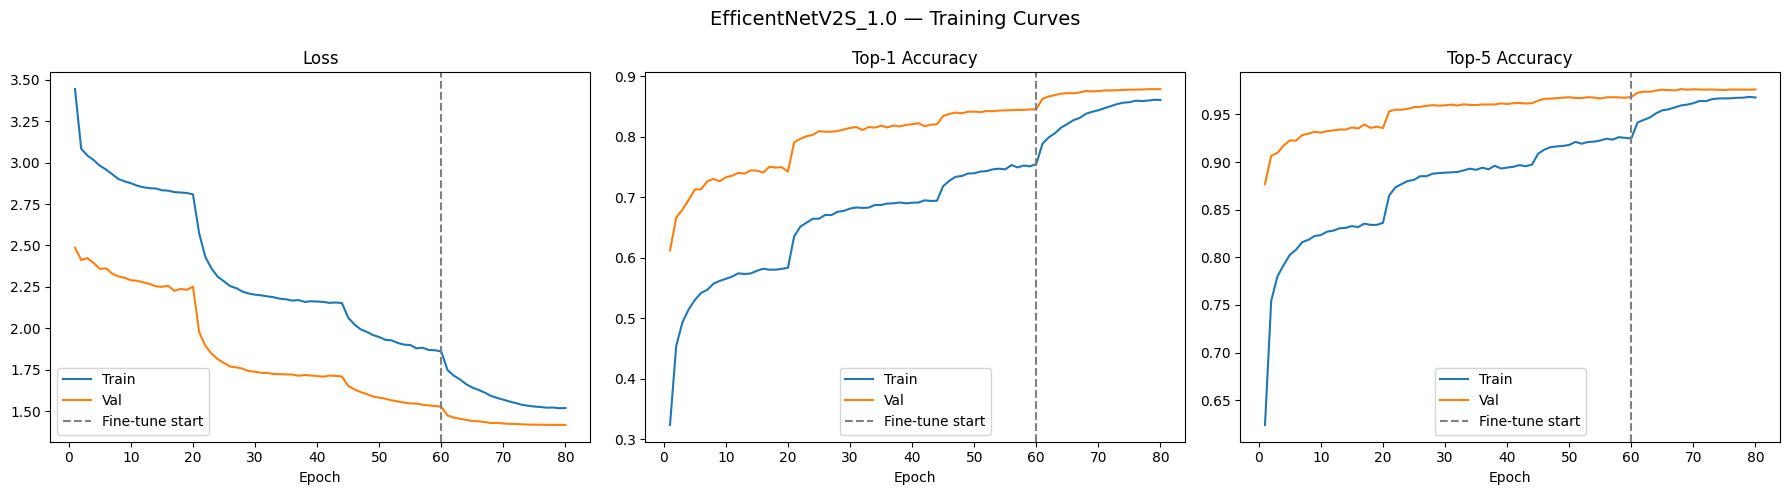

Saved → /tf/data/models/EfficentNetV2S_1.0/EfficentNetV2S_1.0_training_curves.png


In [10]:
#Training Curves
import matplotlib.pyplot as plt
import numpy as np

# -- Combine both phases
def combine_histories(h1, h2, key):
    return h1.history[key] + h2.history[key]

epochs_ht = range(1, len(history_ht.history['accuracy']) + 1)
epochs_ft = range(len(epochs_ht) + 1, len(epochs_ht) + len(history_ft.history['accuracy']) + 1)
all_epochs = list(epochs_ht) + list(epochs_ft)
phase_boundary = len(epochs_ht)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{MODEL_NAME} — Training Curves', fontsize=14)

# -- Loss
axes[0].plot(all_epochs, combine_histories(history_ht, history_ft, 'loss'), label='Train')
axes[0].plot(all_epochs, combine_histories(history_ht, history_ft, 'val_loss'), label='Val')
axes[0].axvline(phase_boundary, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# -- Top-1 Accuracy
axes[1].plot(all_epochs, combine_histories(history_ht, history_ft, 'accuracy'), label='Train')
axes[1].plot(all_epochs, combine_histories(history_ht, history_ft, 'val_accuracy'), label='Val')
axes[1].axvline(phase_boundary, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Top-1 Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# -- Top-5 Accuracy
axes[2].plot(all_epochs, combine_histories(history_ht, history_ft, 'top5_acc'), label='Train')
axes[2].plot(all_epochs, combine_histories(history_ht, history_ft, 'val_top5_acc'), label='Val')
axes[2].axvline(phase_boundary, color='gray', linestyle='--', label='Fine-tune start')
axes[2].set_title('Top-5 Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/{MODEL_NAME}_training_curves.png', dpi=150)
plt.show()
print(f"Saved → {SAVE_DIR}/{MODEL_NAME}_training_curves.png")

Loading best_model_finetuned.keras from /tf/data/models/EfficentNetV2S_1.0/EfficentNetV2S_1.0_final.keras...
Running inference on test set ...


I0000 00:00:1778105743.659753   32869 service.cc:148] XLA service 0x7d2eb4003630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778105743.659840   32869 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2026-05-06 22:15:43.865025: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778105744.684156   32869 cuda_dnn.cc:529] Loaded cuDNN version 92000
E0000 00:00:1778105754.231069   32869 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778105754.435851   32869 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778105755.746662   32


  Top-1 Accuracy : 87.85%
  Top-5 Accuracy : 5.07%

20 worst-performing classes (by F1):
  steak                          F1=0.602
  pork_chop                      F1=0.660
  chocolate_mousse               F1=0.705
  filet_mignon                   F1=0.715
  bread_pudding                  F1=0.717
  apple_pie                      F1=0.724
  tuna_tartare                   F1=0.740
  foie_gras                      F1=0.756
  cheese_plate                   F1=0.763
  chocolate_cake                 F1=0.770
  huevos_rancheros               F1=0.779
  ceviche                        F1=0.783
  beet_salad                     F1=0.788
  crab_cakes                     F1=0.805
  ravioli                        F1=0.809
  gnocchi                        F1=0.809
  omelette                       F1=0.810
  beef_tartare                   F1=0.813
  scallops                       F1=0.813
  grilled_salmon                 F1=0.826


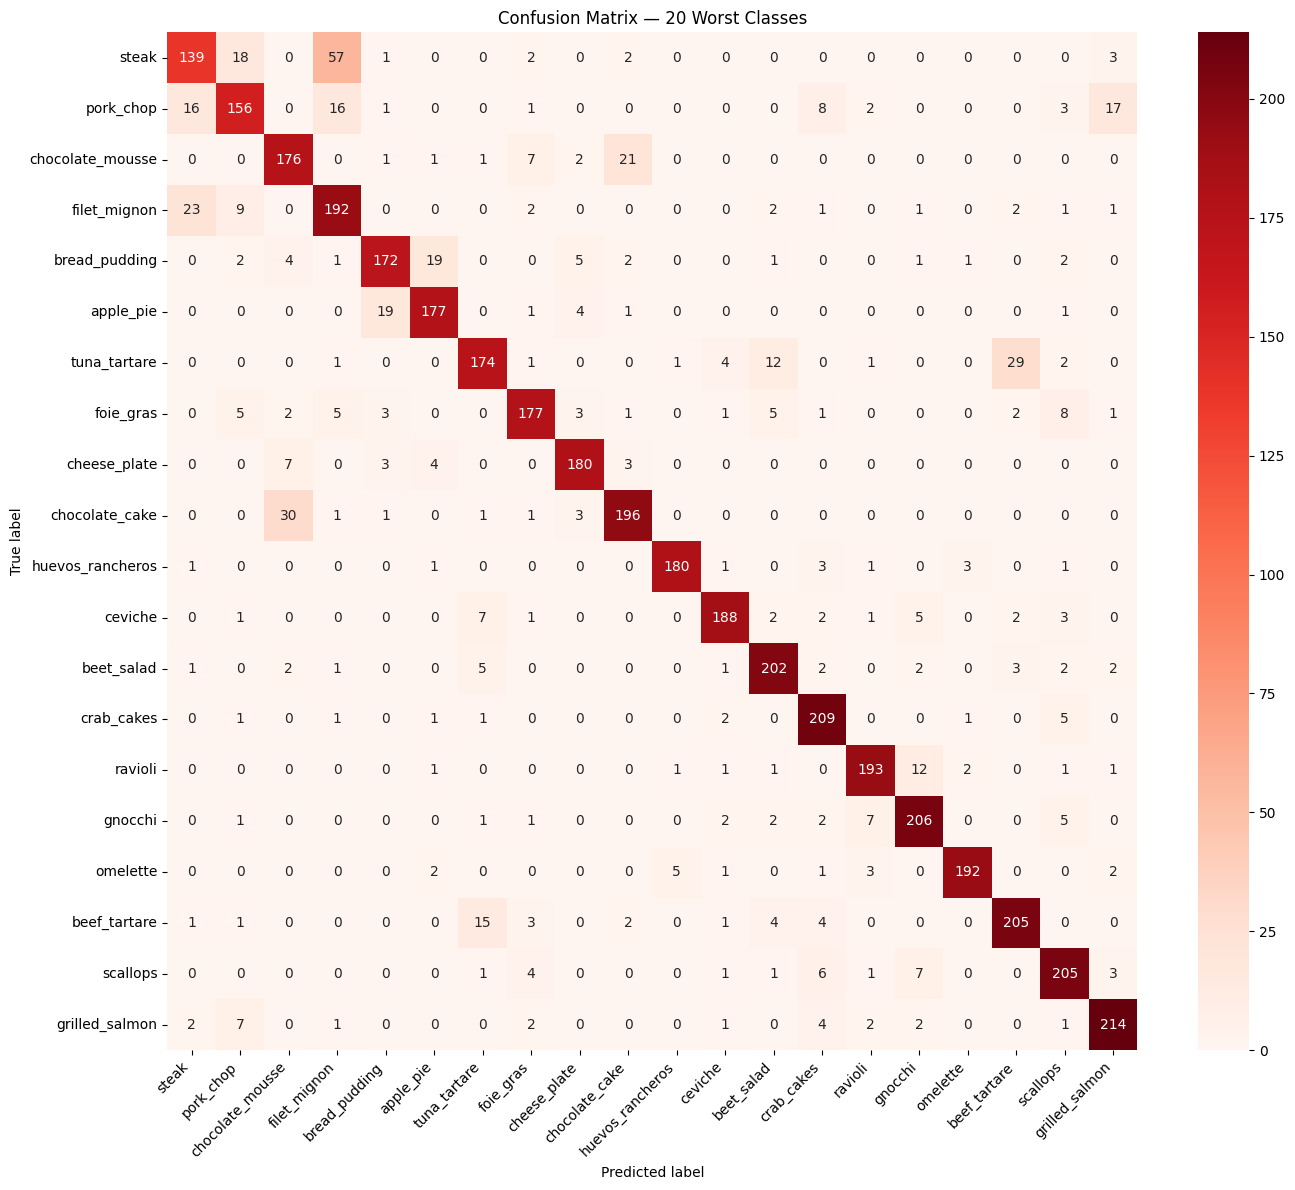

Saved → /tf/data/models/EfficentNetV2S_1.0/EfficentNetV2S_1.0_heatmap.png


In [3]:
# Validation on TEST
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best fine-tuned model (resilient to kernel restart)
try:
    model
except NameError:
    print(f'Loading from {SAVE_DIR}/{MODEL_NAME}_final.keras...')
    model = keras.models.load_model(f'{SAVE_DIR}/{MODEL_NAME}_final.keras')

# Rebuild test_ds if needed
try:
    test_ds
except NameError:
    test_ds = build_dataset(TEST_DIR, augment_data=False)

# Collect predictions
print("Running inference on test set ...")
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Metrics
top1_acc = np.mean(y_true == y_pred)
y_pred_top5 = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    top5 = np.argsort(preds, axis=1)[:, -5:]
    y_pred_top5.extend(top5.tolist())
true_in_top5 = [y_true[i] in y_pred_top5[i] for i in range(len(y_true))]
top5_acc = np.mean(true_in_top5)

print(f"\n{'='*40}")
print(f"  Top-1 Accuracy : {top1_acc*100:.2f}%")
print(f"  Top-5 Accuracy : {top5_acc*100:.2f}%")
print(f"{'='*40}\n")

# Per-class F1
class_names  = [N_class[i] for i in range(N_CLASSES)]
report       = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
per_class_f1 = {cls: report[cls]['f1-score'] for cls in class_names}

worst20 = sorted(per_class_f1.items(), key=lambda x: x[1])[:20]
best20  = sorted(per_class_f1.items(), key=lambda x: x[1], reverse=True)[:20]

print("20 worst-performing classes (by F1):")
for cls, f1 in worst20:
    print(f"  {cls:<30} F1={f1:.3f}")

print("\n20 best-performing classes (by F1):")
for cls, f1 in best20:
    print(f"  {cls:<30} F1={f1:.3f}")

# Confusion matrix — worst 20
worst_indices = [class_names.index(c) for c, _ in worst20]
mask_worst    = np.isin(y_true, worst_indices)
cm_worst      = confusion_matrix(y_true[mask_worst], y_pred[mask_worst], labels=worst_indices)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_worst, annot=True, fmt='d', cmap='Reds',
            xticklabels=[class_names[i] for i in worst_indices],
            yticklabels=[class_names[i] for i in worst_indices])
plt.title(f'{MODEL_NAME} — Confusion Matrix (20 Worst Classes)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/{MODEL_NAME}_heatmap_worst.svg')
plt.show()
print(f"Saved → {SAVE_DIR}/{MODEL_NAME}_heatmap_worst.svg")

# Confusion matrix — best 20
best_indices = [class_names.index(c) for c, _ in best20]
mask_best    = np.isin(y_true, best_indices)
cm_best      = confusion_matrix(y_true[mask_best], y_pred[mask_best], labels=best_indices)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=[class_names[i] for i in best_indices],
            yticklabels=[class_names[i] for i in best_indices])
plt.title(f'{MODEL_NAME} — Confusion Matrix (20 Best Classes)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/{MODEL_NAME}_heatmap_best.svg')
plt.show()
print(f"Saved → {SAVE_DIR}/{MODEL_NAME}_heatmap_best.svg")

In [ ]:
# Clear CACHE
# import subprocess
# result = subprocess.run(
#     'rm -rf /content/*.tempstate* /content/*.lockfile /content/food-101.tar.gz && df -h /content',
#     shell=True, capture_output=True, text=True
# )
# print(result.stdout)
# print(result.stderr)

In [ ]:
# # CLEAN DEAD FILES
# import subprocess

# # Show the biggest directories eating your disk
# result = subprocess.run(
#     ['du', '-sh', '--threshold=100M',
#      '/content/cache_train',
#      '/content/cache_test',
#      '/content/food-101',
#      '/content/drive/.shortcut-targets-by-id',
#      '/root/.keras',
#      '/tmp'],
#     capture_output=True, text=True
# )
# print(result.stdout)
# print(result.stderr)

# # Also show overall breakdown
# print("\n--- Top space consumers in /content ---")
# subprocess.run(['du', '-sh', '/content/*'], shell=False)
# result2 = subprocess.run('du -sh /content/* 2>/dev/null | sort -rh | head -20',
#                          shell=True, capture_output=True, text=True)
# print(result2.stdout)